In [43]:
import pandas as pd

In [44]:
def load_data():
    df = pd.read_csv('HR-Employee-Attrition.csv')
    return df

df = load_data()
print ("Shape:", df.shape)
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [45]:
import numpy as np
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

Text(0.5, 1.0, 'Distribution')

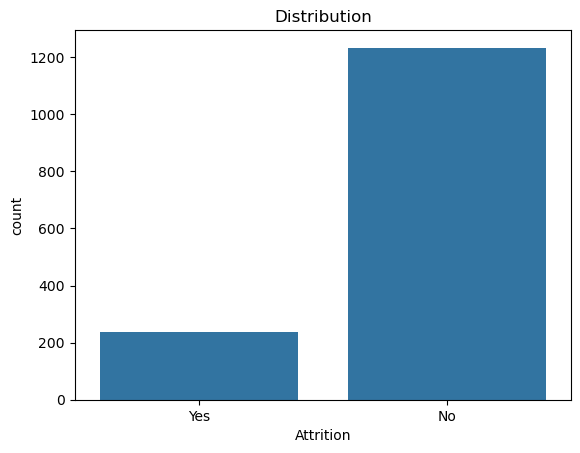

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Attrition', data=df)
plt.title ('Distribution')


In [47]:
def separate_xy(df):
    X = df.drop("Attrition", axis=1)
    y = df["Attrition"].map({"Yes": 1, "No": 0})
    return X, y

X, y = separate_xy(df)

In [48]:
print(y)

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64


In [49]:
def encode_data(X_train, X_test):
    X_train = pd.get_dummies(X_train, drop_first=True)
    X_test = pd.get_dummies(X_test, drop_first=True)
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
    return X_train, X_test

In [50]:
X.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,1,80,0,8,0,1,6,4,0,5
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,4,80,1,10,3,3,10,7,1,7
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,2,80,0,7,3,3,0,0,0,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,3,80,0,8,3,3,8,7,3,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,4,80,1,6,3,3,2,2,2,2


In [51]:
from sklearn.model_selection import train_test_split

def split_data(X, y, test_size=0.2, random_state=42):
    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

X_train, X_test, y_train, y_test = split_data(X, y)
X_train, X_test = encode_data(X_train, X_test)
X_train.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1194,47,1225,2,4,1,1676,2,47,4,4,...,False,True,False,False,False,False,False,False,False,False
128,22,594,2,1,1,169,3,100,3,1,...,True,False,False,False,False,False,False,True,False,False
810,46,406,3,1,1,1124,1,52,3,4,...,False,True,False,False,False,False,False,True,False,False
478,25,622,13,1,1,645,2,40,3,1,...,False,False,False,False,False,False,True,True,False,False
491,43,1001,9,5,1,663,4,72,3,2,...,True,False,False,False,False,False,False,False,False,True


In [52]:
# SMOTE and scaling
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

def prepare_data(X_train, X_test, y_train, y_test, random_state=42):
    # Scale after encoding
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Apply SMOTE only on the training set
    smote = SMOTE(random_state=random_state)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    return X_train, X_test, y_train, y_test

In [53]:
# BEFORE
print("Original distribution:")
print(y.value_counts())

# Apply preprocessing pipeline
X_train, X_test, y_train, y_test = prepare_data(X_train, X_test, y_train, y_test)

# AFTER
print("After SMOTE (training set):")
print(y_train.value_counts())

Original distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64
After SMOTE (training set):
Attrition
0    986
1    986
Name: count, dtype: int64


In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

def train_random_forest(X_train, y_train, X_test, y_test):
    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    return acc, preds

rf_acc, rf_preds = train_random_forest(X_train, y_train, X_test, y_test)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8095238095238095


In [55]:
import numpy as np
from sklearn.utils import resample
from scipy.stats import mode

def bootstrap_vote_predict(model_fns, X_train, y_train, X_test, n_estimators=15):
    
    all_preds = []
    
    for fn in model_fns:
        for _ in range(n_estimators):
            
            # Bootstrap sampling
            X_bs, y_bs = resample(X_train, y_train, replace=True)
            
            # Create and train model
            model = fn()
            model.fit(X_bs, y_bs)
            
            # Predict
            preds = model.predict(X_test)
            all_preds.append(preds)
    
    all_preds = np.array(all_preds)
    
    # Majority voting across bootstrapped models
    final_preds = mode(all_preds, axis=0).mode
    
    return final_preds.ravel()

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

def train_custom_ensemble(X_train, y_train, X_test):
    
    model_list = [
        lambda: DecisionTreeClassifier(max_depth=5),
        lambda: KNeighborsClassifier(n_neighbors=5),
        lambda: LogisticRegression(max_iter=500)
    ]
    
    ensemble_preds = bootstrap_vote_predict(
        model_list, X_train, y_train, X_test
    )
    
    return ensemble_preds


bagger_preds = train_custom_ensemble(X_train, y_train, X_test)

from sklearn.metrics import accuracy_score
bagger_acc = accuracy_score(y_test, bagger_preds)

print("Custom Ensemble Accuracy:", bagger_acc)

Custom Ensemble Accuracy: 0.782312925170068


In [57]:
from sklearn.metrics import accuracy_score

rf_acc = accuracy_score(y_test, rf_preds)
bagger_acc = accuracy_score(y_test, bagger_preds)

In [58]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, rf_preds))
print(confusion_matrix(y_test, bagger_preds))

[[218  29]
 [ 27  20]]
[[201  46]
 [ 18  29]]


In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_preds))
print(classification_report(y_test, bagger_preds))

              precision    recall  f1-score   support

           0       0.89      0.88      0.89       247
           1       0.41      0.43      0.42        47

    accuracy                           0.81       294
   macro avg       0.65      0.65      0.65       294
weighted avg       0.81      0.81      0.81       294

              precision    recall  f1-score   support

           0       0.92      0.81      0.86       247
           1       0.39      0.62      0.48        47

    accuracy                           0.78       294
   macro avg       0.65      0.72      0.67       294
weighted avg       0.83      0.78      0.80       294



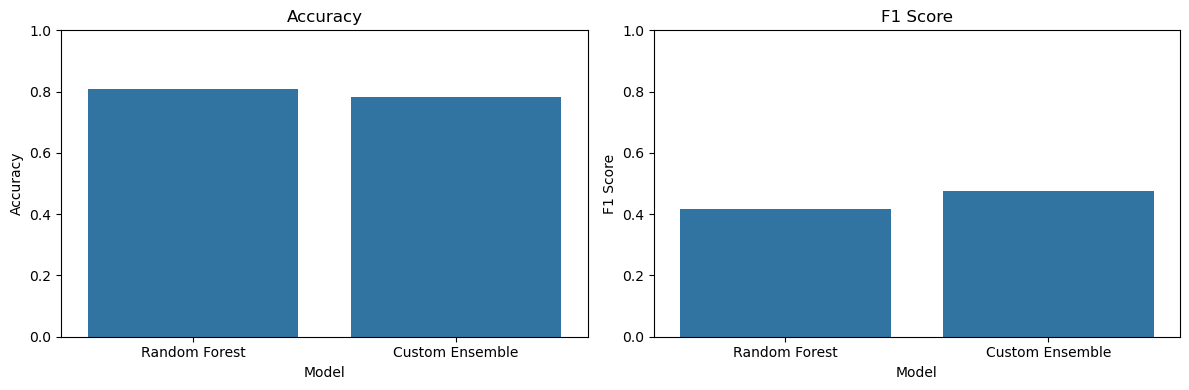

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score

results = pd.DataFrame({
    "Model": ["Random Forest", "Custom Ensemble"],
    "Accuracy": [rf_acc, bagger_acc],
    "F1 Score": [f1_score(y_test, rf_preds), f1_score(y_test, bagger_preds)]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x="Model", y="Accuracy", data=results, ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title("Accuracy")

sns.barplot(x="Model", y="F1 Score", data=results, ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("F1 Score")

plt.tight_layout()
plt.show()